In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,r2_score, classification_report,confusion_matrix

In [82]:
df= pd.read_csv("Customer Churn.csv")

In [83]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [84]:
df.tail()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.98,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.21,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.32,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.64,0
3149,8,1,11,2,1792,25,7,9,3,1,1,30,100.68,1


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)
memory usa

In [86]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [87]:
df.shape

(3150, 14)

In [88]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='str')

# Data Cleaning

In [89]:
df.isna().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(300)

In [91]:
df = df.drop_duplicates()

In [92]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


# Data spliting

In [93]:
x = df.drop(['Churn'],axis=1)
y = df['Churn']

In [94]:
sc = StandardScaler()

# train- test split apply

In [95]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=.2,random_state=42)

In [96]:
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest)

# Logistic Regression Classifier

Training Score :  0.9021929824561403


Test Score :  0.8912280701754386


Accuracy Score :  0.8912280701754386


Classificatin Report

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       479
           1       0.77      0.45      0.57        91

    accuracy                           0.89       570
   macro avg       0.84      0.71      0.75       570
weighted avg       0.88      0.89      0.88       570





<Axes: >

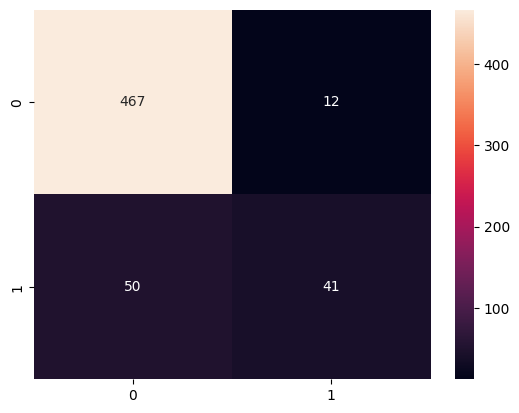

In [97]:
lr = LogisticRegression(max_iter=1000)
# train score 
model_lr = lr.fit(xtrain,ytrain)
print("Training Score : ", model_lr.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_lr.score(xtest,ytest))
print('\n')
#prediction

pred = lr.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_lr = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_lr)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')

# Decision Tree Classifier

Training Score :  0.9964912280701754


Test Score :  0.9280701754385965


Accuracy Score :  0.9280701754385965


Classificatin Report

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       479
           1       0.77      0.78      0.78        91

    accuracy                           0.93       570
   macro avg       0.86      0.87      0.87       570
weighted avg       0.93      0.93      0.93       570





<Axes: >

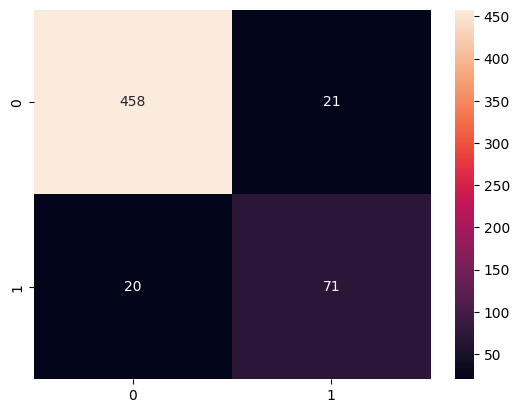

In [98]:
dt = DecisionTreeClassifier()

# train score 
model_dt = dt.fit(xtrain,ytrain)
print("Training Score : ", model_dt.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_dt.score(xtest,ytest))
print('\n')
#prediction

pred = dt.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_dt = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_dt)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# Random Forest Classifier

Training Score :  0.9964912280701754


Test Score :  0.956140350877193


Accuracy Score :  0.956140350877193


Classificatin Report

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       479
           1       0.90      0.81      0.86        91

    accuracy                           0.96       570
   macro avg       0.93      0.90      0.91       570
weighted avg       0.96      0.96      0.96       570





<Axes: >

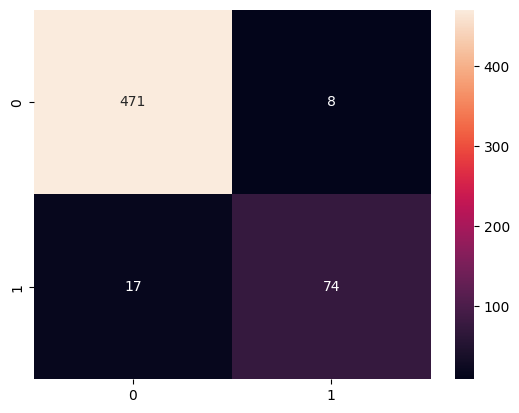

In [99]:
rf = RandomForestClassifier()

# train score 
model_rf = rf.fit(xtrain,ytrain)
print("Training Score : ", model_rf.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_rf.score(xtest,ytest))
print('\n')
#prediction

pred = rf.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_rf = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_rf)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# SVM Classifier

Training Score :  0.9307017543859649


Test Score :  0.9210526315789473


Accuracy Score :  0.9210526315789473


Classificatin Report

              precision    recall  f1-score   support

           0       0.92      0.99      0.95       479
           1       0.91      0.56      0.69        91

    accuracy                           0.92       570
   macro avg       0.92      0.78      0.82       570
weighted avg       0.92      0.92      0.91       570





<Axes: >

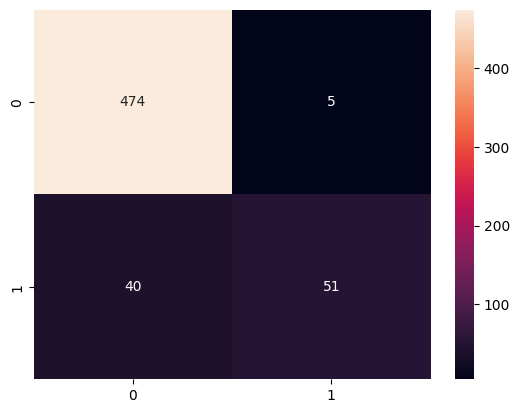

In [100]:
svm = SVC()

# train score 
model_svm = svm.fit(xtrain,ytrain)
print("Training Score : ", model_svm.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_svm.score(xtest,ytest))
print('\n')
#prediction

pred = svm.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_svm = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_svm)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# KNN Classifier

Training Score :  0.9723684210526315


Test Score :  0.9421052631578948


Accuracy Score :  0.9421052631578948


Classificatin Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       479
           1       0.85      0.77      0.81        91

    accuracy                           0.94       570
   macro avg       0.91      0.87      0.89       570
weighted avg       0.94      0.94      0.94       570





<Axes: >

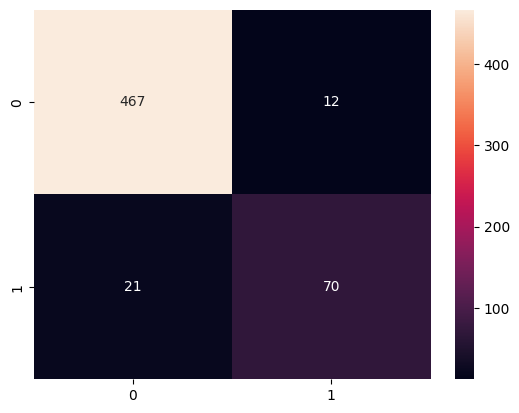

In [101]:
knn = KNeighborsClassifier(n_neighbors=5)

# train score 
model_knn = knn.fit(xtrain,ytrain)
print("Training Score : ", model_knn.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_knn.score(xtest,ytest))
print('\n')
#prediction

pred = knn.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_knn = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_knn)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


 # Neive Bayes Classifier

Training Score :  0.7337719298245614


Test Score :  0.7473684210526316


Accuracy Score :  0.7473684210526316


Classificatin Report

              precision    recall  f1-score   support

           0       0.98      0.72      0.83       479
           1       0.38      0.91      0.54        91

    accuracy                           0.75       570
   macro avg       0.68      0.81      0.68       570
weighted avg       0.88      0.75      0.78       570





<Axes: >

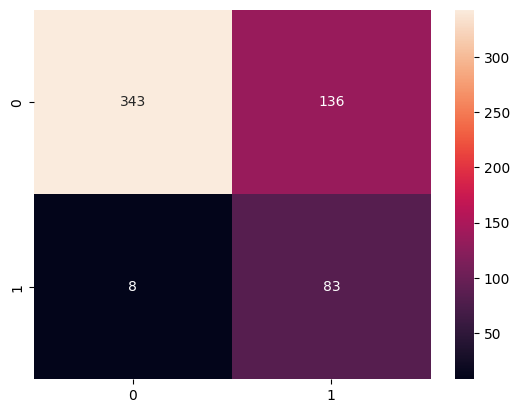

In [102]:
nb = GaussianNB()

# train score 
model_nb = nb.fit(xtrain,ytrain)
print("Training Score : ", model_nb.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_nb.score(xtest,ytest))
print('\n')
#prediction

pred = nb.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_nb = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_nb)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# GBM Classifier

Training Score :  0.9692982456140351


Test Score :  0.9403508771929825


Accuracy Score :  0.9403508771929825


Classificatin Report

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       479
           1       0.88      0.73      0.80        91

    accuracy                           0.94       570
   macro avg       0.91      0.85      0.88       570
weighted avg       0.94      0.94      0.94       570





<Axes: >

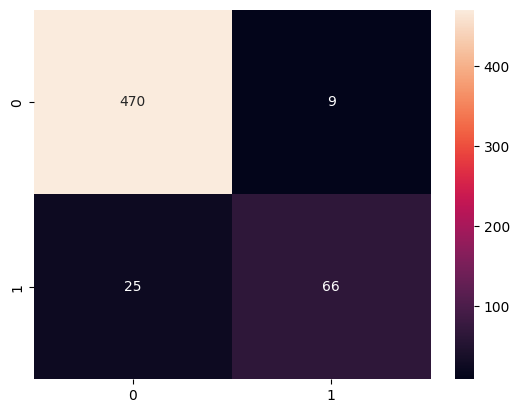

In [103]:
gbm = GradientBoostingClassifier()

# train score 
model_gbm = gbm.fit(xtrain,ytrain)
print("Training Score : ", model_gbm.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_gbm.score(xtest,ytest))
print('\n')
#prediction

pred = gbm.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_gbm = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_gbm)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# ANN Classifier

Training Score :  0.962280701754386


Test Score :  0.9543859649122807


Accuracy Score :  0.9543859649122807


Classificatin Report

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       479
           1       0.95      0.76      0.84        91

    accuracy                           0.95       570
   macro avg       0.95      0.87      0.91       570
weighted avg       0.95      0.95      0.95       570





c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


<Axes: >

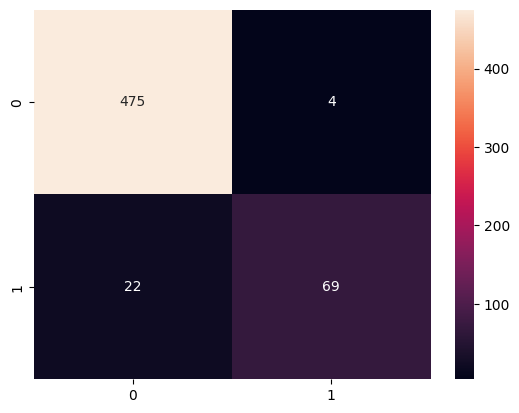

In [104]:
ann= MLPClassifier()

# train score 
model_ann = ann.fit(xtrain,ytrain)
print("Training Score : ", model_ann.score(xtrain,ytrain))
print('\n')
# test score 
print("Test Score : ", model_ann.score(xtest,ytest))
print('\n')
#prediction

pred = ann.predict(xtest)

# Model Evaluation


 # accuracy Score 
acc_scor_ann = accuracy_score(ytest,pred)
print("Accuracy Score : ",acc_scor_ann)
print('\n')

# Classification Report
class_rep = classification_report(ytest,pred)
print("Classificatin Report\n")
print(class_rep)
print('\n')


# confusio matrix 
con_max = confusion_matrix(ytest, pred)
sns.heatmap(con_max,annot=True,fmt='d')


# Final Analysis 

In [108]:
print("Logistic Regression Accuracy Score : ",acc_scor_lr )
print("\n")
print("Decision Tree Accuracy Score : ",acc_scor_dt )
print("\n")
print("Random Forest Accuracy Score : ",acc_scor_rf )
print("\n")
print("Neive Bayes Accuracy Score : ",acc_scor_nb )
print("\n")
print("SVM Accuracy Score : ",acc_scor_svm )
print("\n")
print("KNN Accuracy Score : ",acc_scor_knn )
print("\n")
print("GBM  Accuracy Score : ",acc_scor_gbm )
print("\n")
print("ANN Accuracy Score : ",acc_scor_ann )


Logistic Regression Accuracy Score :  0.8912280701754386


Decision Tree Accuracy Score :  0.9280701754385965


Random Forest Accuracy Score :  0.956140350877193


Neive Bayes Accuracy Score :  0.7473684210526316


SVM Accuracy Score :  0.9210526315789473


KNN Accuracy Score :  0.9421052631578948


GBM  Accuracy Score :  0.9403508771929825


ANN Accuracy Score :  0.9543859649122807


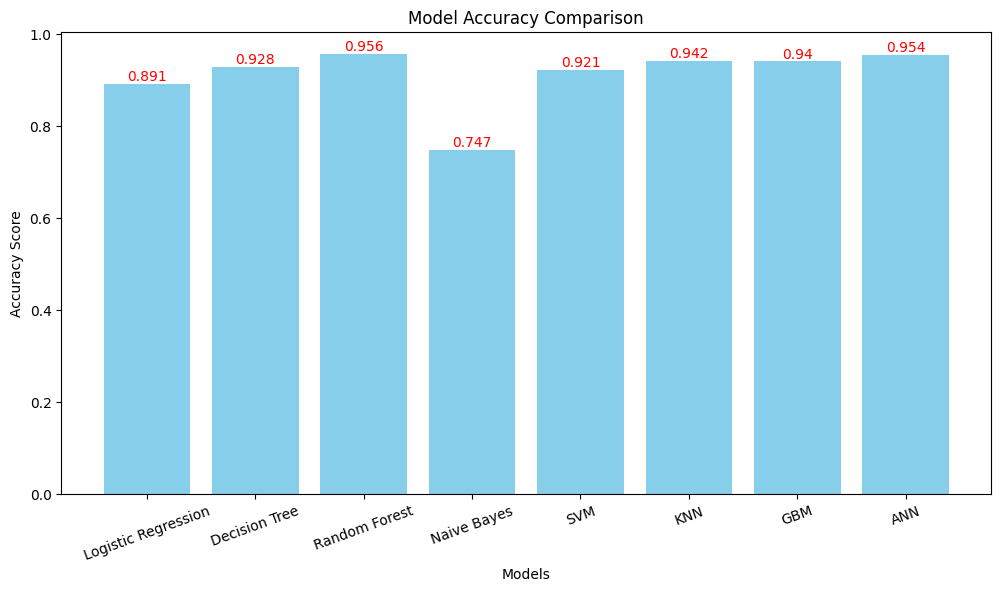

In [118]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Naive Bayes',
    'SVM',
    'KNN',
    'GBM',
    'ANN'
]

scores = [
    acc_scor_lr,
    acc_scor_dt,
    acc_scor_rf,
    acc_scor_nb,
    acc_scor_svm,
    acc_scor_knn,
    acc_scor_gbm,
    acc_scor_ann
]

plt.figure(figsize=(12,6))

bars = plt.bar(models, scores,color= 'skyblue')

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy Score")

plt.xticks(rotation=20)

# accuracy value on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,yval,round(yval, 3),ha='center',va='bottom', color= 'red')

plt.show()